# Phase 2c: Sensor Forecasting on MetroPT-3

**Goal:** forecast one or two key sensors (`TP2` pressure and `Oil_temperature`) up to **6 hours ahead**, with a confidence band. This feeds the *forecast plot* panel of the dashboard.

**Methods compared**
1. **Naive:** the future equals the last value (the baseline every model must beat)
2. **Seasonal naive:** the future equals the value 24 hours earlier
3. **Prophet:** trend plus daily and weekly seasonality, refitted on the last 14 days
4. **Prophet + level correction:** Prophet shifted by how far the most recent readings are from its fit
5. *(optional)* **N-BEATS** via the `darts` library

**Evaluation:** rolling origin. We pick many start times in normal operation, forecast the next 6 hours, and compare with what really happened. A model only counts if it beats the naive baseline.

**Needs:** `data/processed/metropt3_labeled.parquet` and `failures.json`.
Install once: `pip install prophet` (N-BEATS needs `pip install darts`, optional).

## 0. Imports and config

In [1]:
import json, logging, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet

warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
logging.getLogger("prophet").setLevel(logging.ERROR)
sns.set_theme(style="whitegrid")

PROC_DIR = Path("../data/processed")
MODEL_DIR = Path("../ml/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ---- tunable settings ----
TARGET_SENSORS = ["TP2", "Oil_temperature"]
WINDOW = "10min"
STEPS = 36                             # 36 x 10 min = 6 hours ahead
HISTORY_DAYS = 14                      # Prophet is refitted on the last 14 days of normal data
N_ORIGINS = 24                         # number of forecast start times used for evaluation
ORIGIN_START = pd.Timestamp("2020-03-01")
INTERVAL = 0.9                         # 90% confidence band
LEVEL_DECAY = 0.95                     # how fast the level correction fades per step
MARGIN = pd.Timedelta("24h")           # keep away from failures by this much
RUN_NBEATS = False                     # set True only if darts is installed
STEP = pd.Timedelta(WINDOW)

Importing plotly failed. Interactive plots will not work.


## 1. Load data and build 10-minute sensor series

In [2]:
df = pd.read_parquet(PROC_DIR / "metropt3_labeled.parquet")
with open(PROC_DIR / "failures.json") as f:
    failures = [(pd.Timestamp(x["start"]), pd.Timestamp(x["end"])) for x in json.load(f)]

counts = df[TARGET_SENSORS[0]].resample(WINDOW).count()
typical = counts[counts > 0].median()

series = {}
for sensor in TARGET_SENSORS:
    s = df[sensor].resample(WINDOW).mean()
    s[counts < 0.5 * typical] = np.nan          # machine off / data gap
    series[sensor] = s

# failure zones (failure +/- 24 h) are excluded from fitting and evaluation
grid = series[TARGET_SENSORS[0]].index
zone = np.zeros(len(grid), dtype=bool)
for s_, e_ in failures:
    zone |= (grid >= s_ - MARGIN) & (grid <= e_ + MARGIN)
zone = pd.Series(zone, index=grid)

print("Series length:", len(grid), "windows | missing:", {k: int(v.isna().sum()) for k, v in series.items()})
print("Windows inside failure zones:", int(zone.sum()))

Series length: 30696 windows | missing: {'TP2': 5440, 'Oil_temperature': 5440}
Windows inside failure zones: 1680


## 2. Look at the signals

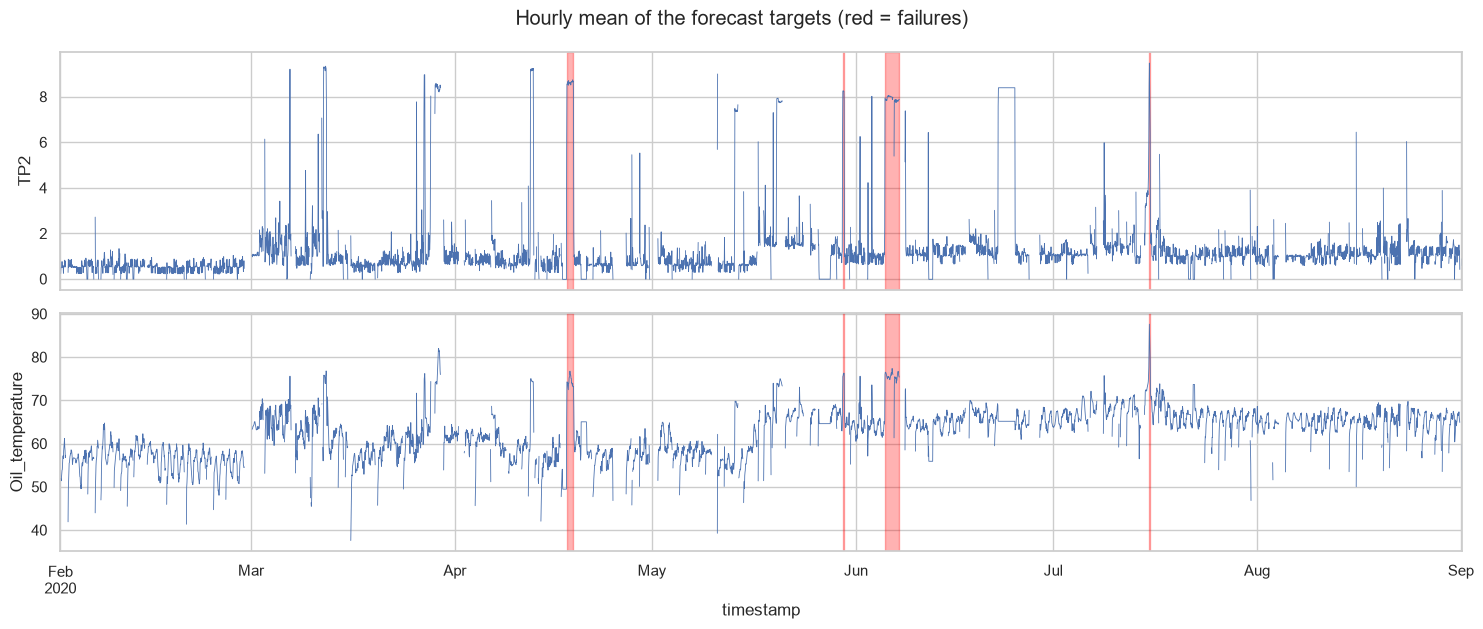

In [3]:
fig, axes = plt.subplots(len(TARGET_SENSORS), 1, figsize=(15, 3.2 * len(TARGET_SENSORS)), sharex=True)
axes = np.atleast_1d(axes)
for ax, sensor in zip(axes, TARGET_SENSORS):
    series[sensor].resample("1h").mean().plot(ax=ax, lw=0.6)
    for s_, e_ in failures:
        ax.axvspan(s_, e_, color="red", alpha=0.3)
    ax.set_ylabel(sensor)
plt.suptitle("Hourly mean of the forecast targets (red = failures)")
plt.tight_layout()
plt.show()

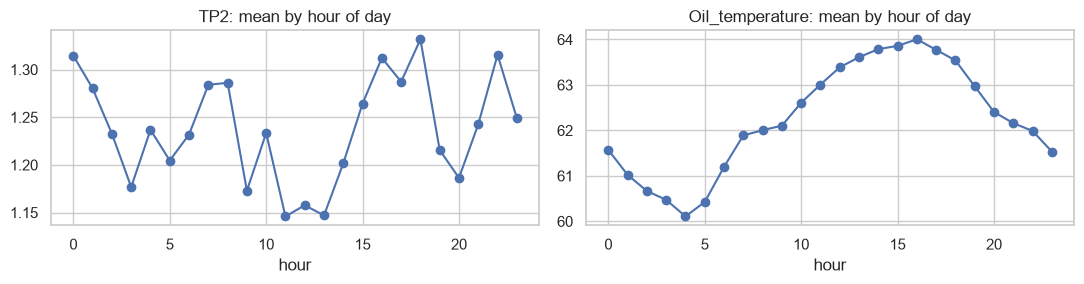

In [4]:
# Is there a daily pattern? (Prophet only helps if there is)
fig, axes = plt.subplots(1, len(TARGET_SENSORS), figsize=(11, 3))
axes = np.atleast_1d(axes)
for ax, sensor in zip(axes, TARGET_SENSORS):
    s = series[sensor].where(~zone)
    s.groupby(s.index.hour).mean().plot(ax=ax, marker="o")
    ax.set_title(f"{sensor}: mean by hour of day")
    ax.set_xlabel("hour")
plt.tight_layout()
plt.show()

## 3. Forecast functions

Prophet only knows trend and seasonality, not what happened in the last hour.
The **level correction** fixes that: it measures how far the latest readings sit from Prophet's own fit and shifts the forecast by that amount, fading out over time.

In [5]:
def prophet_level_forecast(hist, steps=STEPS, interval=INTERVAL, decay=LEVEL_DECAY):
    # hist: pd.Series of 10-minute means (no NaN). Returns a DataFrame with plain and level-corrected forecasts.
    d = pd.DataFrame({"ds": hist.index, "y": hist.values})
    m = Prophet(interval_width=interval, daily_seasonality=True, weekly_seasonality=True,
                yearly_seasonality=False, changepoint_prior_scale=0.05)
    m.fit(d)

    future_idx = pd.date_range(hist.index[-1] + STEP, periods=steps, freq=WINDOW)
    fc = m.predict(pd.DataFrame({"ds": future_idx}))[["ds", "yhat", "yhat_lower", "yhat_upper"]].copy()

    # level correction: how far are the last 6 readings from Prophet's in-sample fit?
    fitted_tail = m.predict(d[["ds"]].tail(6))["yhat"].values
    offset = float(np.mean(d["y"].tail(6).values - fitted_tail))
    fade = decay ** np.arange(1, steps + 1)
    fc["yhat_lvl"] = fc["yhat"] + offset * fade
    fc["lower_lvl"] = fc["yhat_lower"] + offset * fade
    fc["upper_lvl"] = fc["yhat_upper"] + offset * fade
    return fc.set_index("ds")


def pick_origins(s_full, s_norm, n=N_ORIGINS, start=ORIGIN_START):
    # Choose forecast start times (every 6 h on the hour) that have enough history and a fully normal future.
    cand = []
    for t0 in s_full.index[(s_full.index >= start) & (s_full.index.minute == 0) & (s_full.index.hour % 6 == 0)]:
        if np.isnan(s_norm.get(t0, np.nan)):
            continue
        fut_idx = pd.date_range(t0 + STEP, periods=STEPS, freq=WINDOW)
        if fut_idx[-1] > s_full.index[-1] or zone.reindex(fut_idx).fillna(True).any():
            continue
        fut = s_full.reindex(fut_idx)
        if fut.notna().mean() < 0.8:
            continue
        hist = s_norm[t0 - pd.Timedelta(days=HISTORY_DAYS): t0].dropna()
        if len(hist) < 0.6 * HISTORY_DAYS * 144:
            continue
        cand.append(t0)
    if len(cand) <= n:
        return cand
    return [cand[i] for i in np.linspace(0, len(cand) - 1, n).astype(int)]

## 4. Rolling-origin evaluation

For every start time `t0`: fit on the previous 14 days (normal data only), forecast the next 6 hours, and compare with the real values.
This takes a few minutes because Prophet is refitted for each origin.

In [6]:
records = {s: [] for s in TARGET_SENSORS}
for sensor in TARGET_SENSORS:
    s_full = series[sensor]
    s_norm = s_full.where(~zone)
    origins = pick_origins(s_full, s_norm)
    print(f"{sensor}: {len(origins)} forecast origins")

    for t0 in origins:
        fut_idx = pd.date_range(t0 + STEP, periods=STEPS, freq=WINDOW)
        actual = s_full.reindex(fut_idx).values
        hist = s_norm[t0 - pd.Timedelta(days=HISTORY_DAYS): t0].dropna()

        last = hist.iloc[-1]
        naive = np.full(STEPS, last)
        snaive = s_norm.reindex(fut_idx - pd.Timedelta("24h")).values
        snaive = np.where(np.isnan(snaive), last, snaive)

        fc = prophet_level_forecast(hist)
        records[sensor].append({
            "origin": t0, "hist": hist, "fut_idx": fut_idx, "actual": actual,
            "naive": naive, "seasonal_naive": snaive,
            "prophet": fc["yhat"].values, "prophet_lo": fc["yhat_lower"].values, "prophet_hi": fc["yhat_upper"].values,
            "prophet_level": fc["yhat_lvl"].values, "level_lo": fc["lower_lvl"].values, "level_hi": fc["upper_lvl"].values,
        })
print("Done.")

TP2: 24 forecast origins


00:41:59 - cmdstanpy - INFO - Chain [1] start processing
00:41:59 - cmdstanpy - INFO - Chain [1] done processing
00:42:00 - cmdstanpy - INFO - Chain [1] start processing
00:42:00 - cmdstanpy - INFO - Chain [1] done processing
00:42:00 - cmdstanpy - INFO - Chain [1] start processing
00:42:00 - cmdstanpy - INFO - Chain [1] done processing
00:42:01 - cmdstanpy - INFO - Chain [1] start processing
00:42:01 - cmdstanpy - INFO - Chain [1] done processing
00:42:01 - cmdstanpy - INFO - Chain [1] start processing
00:42:01 - cmdstanpy - INFO - Chain [1] done processing
00:42:02 - cmdstanpy - INFO - Chain [1] start processing
00:42:02 - cmdstanpy - INFO - Chain [1] done processing
00:42:02 - cmdstanpy - INFO - Chain [1] start processing
00:42:02 - cmdstanpy - INFO - Chain [1] done processing
00:42:02 - cmdstanpy - INFO - Chain [1] start processing
00:42:03 - cmdstanpy - INFO - Chain [1] done processing
00:42:03 - cmdstanpy - INFO - Chain [1] start processing
00:42:03 - cmdstanpy - INFO - Chain [1]

Oil_temperature: 24 forecast origins


00:42:10 - cmdstanpy - INFO - Chain [1] done processing
00:42:10 - cmdstanpy - INFO - Chain [1] start processing
00:42:10 - cmdstanpy - INFO - Chain [1] done processing
00:42:10 - cmdstanpy - INFO - Chain [1] start processing
00:42:10 - cmdstanpy - INFO - Chain [1] done processing
00:42:11 - cmdstanpy - INFO - Chain [1] start processing
00:42:11 - cmdstanpy - INFO - Chain [1] done processing
00:42:11 - cmdstanpy - INFO - Chain [1] start processing
00:42:11 - cmdstanpy - INFO - Chain [1] done processing
00:42:11 - cmdstanpy - INFO - Chain [1] start processing
00:42:12 - cmdstanpy - INFO - Chain [1] done processing
00:42:12 - cmdstanpy - INFO - Chain [1] start processing
00:42:12 - cmdstanpy - INFO - Chain [1] done processing
00:42:12 - cmdstanpy - INFO - Chain [1] start processing
00:42:12 - cmdstanpy - INFO - Chain [1] done processing
00:42:13 - cmdstanpy - INFO - Chain [1] start processing
00:42:13 - cmdstanpy - INFO - Chain [1] done processing
00:42:13 - cmdstanpy - INFO - Chain [1] 

Done.


## 5. Optional: N-BEATS (deep learning)

Skipped unless `RUN_NBEATS = True` and `darts` is installed (`pip install darts`, large download).
It is trained once on the early normal period and then forecasts from the recent history at every origin.

In [7]:
METHODS = ["naive", "seasonal_naive", "prophet", "prophet_level"]

if RUN_NBEATS:
    try:
        from darts import TimeSeries
        from darts.models import NBEATSModel
        from darts.dataprocessing.transformers import Scaler
        from darts.utils.missing_values import fill_missing_values

        def to_ts(s):
            ts = TimeSeries.from_series(s.asfreq(WINDOW), freq=WINDOW, fill_missing_dates=True)
            return fill_missing_values(ts)

        for sensor in TARGET_SENSORS:
            s_norm = series[sensor].where(~zone)
            train = s_norm[: ORIGIN_START].dropna()
            scaler = Scaler()
            train_ts = scaler.fit_transform(to_ts(train))
            model = NBEATSModel(input_chunk_length=144, output_chunk_length=STEPS, n_epochs=15,
                                random_state=42, pl_trainer_kwargs={"accelerator": "cpu"})
            model.fit(train_ts, verbose=False)
            for r in records[sensor]:
                recent = s_norm[r["origin"] - pd.Timedelta(days=3): r["origin"]]
                pred = model.predict(n=STEPS, series=scaler.transform(to_ts(recent)), verbose=False)
                r["nbeats"] = scaler.inverse_transform(pred).values().ravel()
        METHODS.append("nbeats")
        print("N-BEATS done.")
    except Exception as exc:
        print("N-BEATS skipped:", repr(exc))
else:
    print("N-BEATS not run (RUN_NBEATS = False).")

N-BEATS not run (RUN_NBEATS = False).


## 6. Results

- **MAE** = mean absolute error in the sensor's own units (lower is better), overall and for 1 h / 3 h / 6 h ahead.
- **skill vs naive** = 1 - MAE / MAE_naive. Positive means better than the naive baseline, negative means worse.

In [8]:
def method_mae(recs, method, sl=slice(None)):
    a = np.array([r["actual"][sl] for r in recs])
    p = np.array([r[method][sl] for r in recs])
    return float(np.nanmean(np.abs(a - p)))

rows = []
for sensor in TARGET_SENSORS:
    recs = records[sensor]
    base = method_mae(recs, "naive")
    for m in METHODS:
        mae_all = method_mae(recs, m)
        rows.append({"sensor": sensor, "method": m,
                     "MAE_all": mae_all,
                     "MAE_1h": method_mae(recs, m, slice(0, 6)),
                     "MAE_3h": method_mae(recs, m, slice(0, 18)),
                     "MAE_6h": method_mae(recs, m, slice(0, 36)),
                     "skill_vs_naive": 1 - mae_all / base if base > 0 else np.nan})
results = pd.DataFrame(rows).set_index(["sensor", "method"])
results.round(3)

MAE_all  MAE_1h  MAE_3h  MAE_6h  \
sensor          method                                            
TP2             naive             1.085   1.126   1.080   1.085   
                seasonal_naive    1.050   1.201   1.067   1.050   
                prophet           1.092   1.053   1.051   1.092   
                prophet_level     1.012   0.914   0.944   1.012   
Oil_temperature naive             3.369   3.229   3.383   3.369   
                seasonal_naive    3.353   3.806   3.386   3.353   
                prophet           3.260   3.253   3.136   3.260   
                prophet_level     2.789   2.485   2.494   2.789   

                                skill_vs_naive  
sensor          method                          
TP2             naive                    0.000  
                seasonal_naive           0.033  
                prophet                 -0.007  
                prophet_level            0.067  
Oil_temperature naive                    0.000  
                seasonal_naive           0.005  
                prophet                  0.032  
                prophet_level            0.172

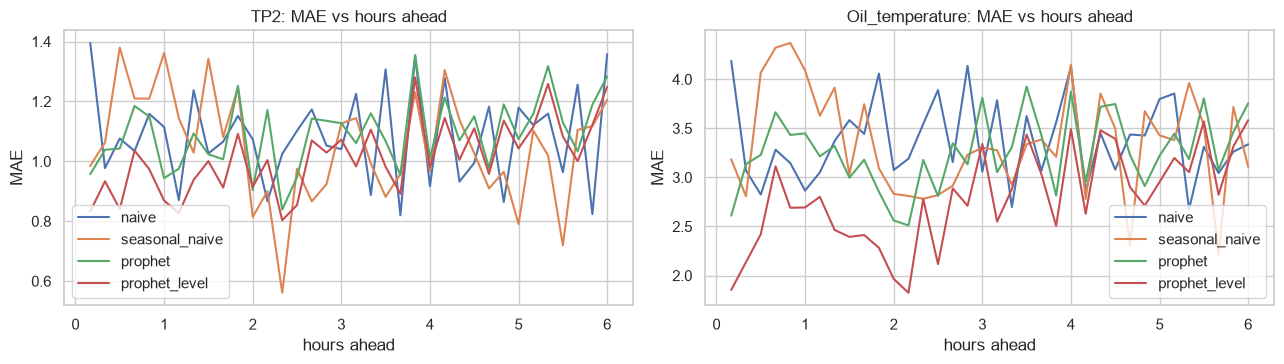

In [9]:
# Error versus forecast horizon: how fast does each method degrade?
fig, axes = plt.subplots(1, len(TARGET_SENSORS), figsize=(6.5 * len(TARGET_SENSORS), 3.8))
axes = np.atleast_1d(axes)
for ax, sensor in zip(axes, TARGET_SENSORS):
    recs = records[sensor]
    for m in METHODS:
        a = np.array([r["actual"] for r in recs])
        p = np.array([r[m] for r in recs])
        ax.plot((np.arange(STEPS) + 1) / 6, np.nanmean(np.abs(a - p), axis=0), label=m)
    ax.set_title(f"{sensor}: MAE vs hours ahead")
    ax.set_xlabel("hours ahead")
    ax.set_ylabel("MAE")
    ax.legend()
plt.tight_layout()
plt.show()

## 7. Is the confidence band honest?

A 90% band should contain about 90% of the real values. Much lower means the band is too narrow (overconfident), much higher means it is too wide to be useful.

In [10]:
cov_rows = []
for sensor in TARGET_SENSORS:
    recs = records[sensor]
    a = np.array([r["actual"] for r in recs])
    for name, lo_key, hi_key in [("prophet", "prophet_lo", "prophet_hi"), ("prophet_level", "level_lo", "level_hi")]:
        lo = np.array([r[lo_key] for r in recs]); hi = np.array([r[hi_key] for r in recs])
        ok = ~np.isnan(a)
        inside = ((a >= lo) & (a <= hi))[ok].mean()
        cov_rows.append({"sensor": sensor, "method": name,
                         "coverage": inside, "target": INTERVAL,
                         "mean_band_width": float(np.nanmean(hi - lo))})
pd.DataFrame(cov_rows).round(3)

,sensor,method,coverage,target,mean_band_width
0,TP2,prophet,0.911,0.9,4.245
1,TP2,prophet_level,0.935,0.9,4.245
2,Oil_temperature,prophet,0.833,0.9,10.039
3,Oil_temperature,prophet_level,0.885,0.9,10.039


## 8. Example forecasts (what the dashboard panel will show)

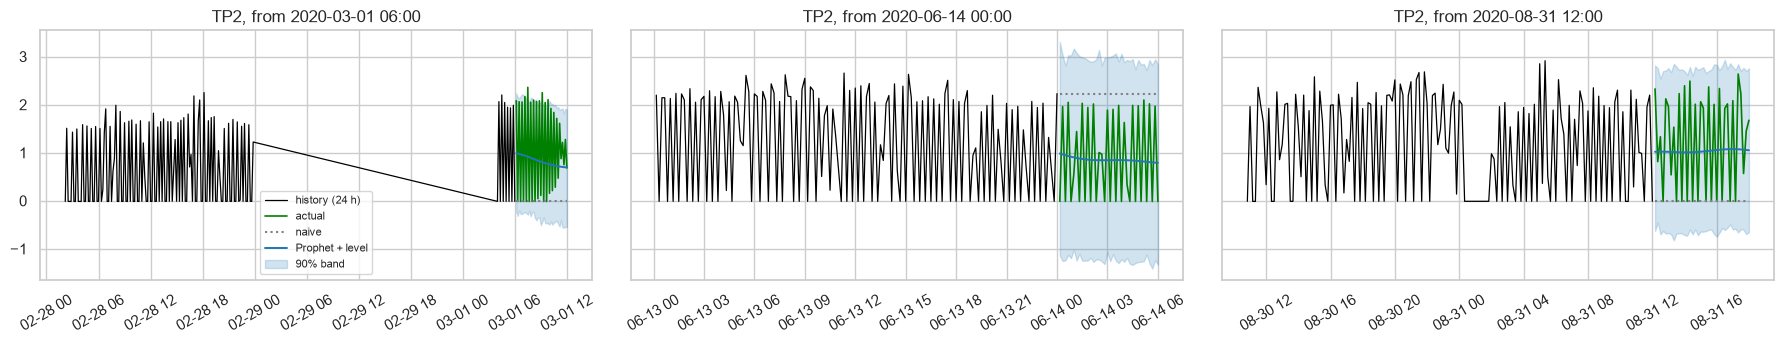

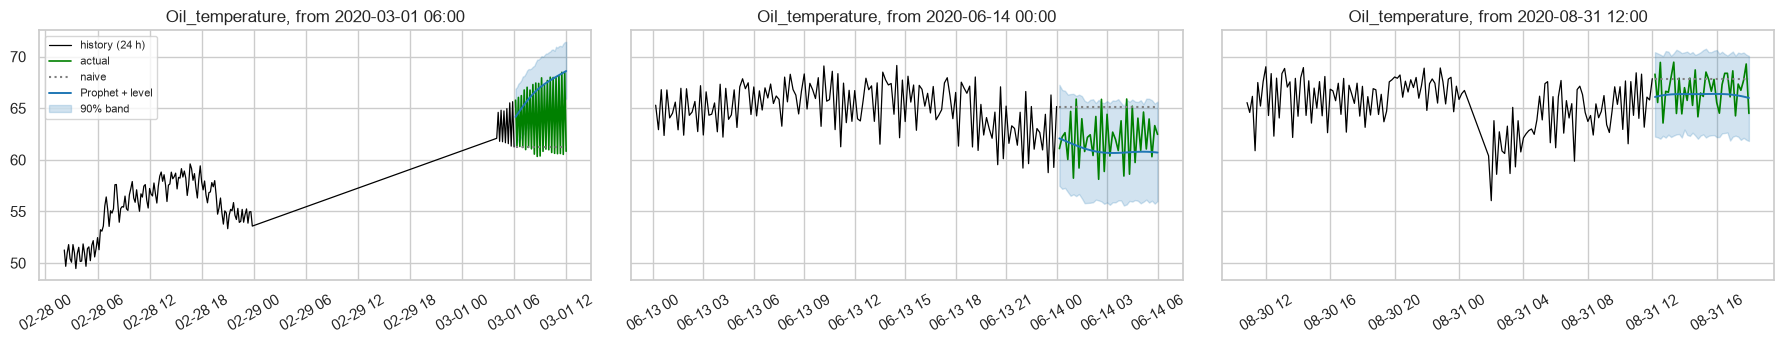

In [11]:
for sensor in TARGET_SENSORS:
    recs = records[sensor]
    picks = [recs[i] for i in sorted({0, len(recs) // 2, len(recs) - 1})]
    fig, axes = plt.subplots(1, len(picks), figsize=(6 * len(picks), 3.6), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, r in zip(axes, picks):
        h = r["hist"].iloc[-6 * 24:]
        ax.plot(h.index, h.values, color="black", lw=0.9, label="history (24 h)")
        ax.plot(r["fut_idx"], r["actual"], color="green", lw=1.2, label="actual")
        ax.plot(r["fut_idx"], r["naive"], color="gray", ls=":", label="naive")
        ax.plot(r["fut_idx"], r["prophet_level"], color="tab:blue", lw=1.4, label="Prophet + level")
        ax.fill_between(r["fut_idx"], r["level_lo"], r["level_hi"], color="tab:blue", alpha=0.2, label="90% band")
        ax.set_title(f"{sensor}, from {r['origin']:%Y-%m-%d %H:%M}")
        ax.tick_params(axis="x", rotation=30)
    axes[0].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

## 9. Pick the method per sensor and save the settings

The best method is the one with the lowest overall MAE. If nothing beats **naive**, say so: it is a legitimate finding, and the dashboard can then simply show the naive forecast.

In [12]:
best = {}
for sensor in TARGET_SENSORS:
    sub = results.loc[sensor]
    best[sensor] = sub["MAE_all"].idxmin()
    print(f"{sensor}: best method = {best[sensor]} (skill vs naive = {sub.loc[best[sensor], 'skill_vs_naive']:.2f})")

config = {
    "sensors": TARGET_SENSORS,
    "window": WINDOW,
    "steps": STEPS,
    "history_days": HISTORY_DAYS,
    "interval_width": INTERVAL,
    "level_decay": LEVEL_DECAY,
    "best_method": best,
    "mae_all": {s: {m: float(results.loc[(s, m), "MAE_all"]) for m in METHODS} for s in TARGET_SENSORS},
    "note": "Prophet is refitted on the last history_days of normal data at forecast time; nothing is pickled.",
}
with open(MODEL_DIR / "forecast_config.json", "w") as f:
    json.dump(config, f, indent=2)
print("Saved", MODEL_DIR / "forecast_config.json")

TP2: best method = prophet_level (skill vs naive = 0.07)
Oil_temperature: best method = prophet_level (skill vs naive = 0.17)
Saved ..\ml\models\forecast_config.json


## 10. Notes (fill these in)

- Did any method clearly beat the naive baseline? At which horizons (1 h, 3 h, 6 h)? ...
- Did the level correction help compared with plain Prophet? ...
- Is the 90% band close to 90% coverage, or too narrow / too wide? ...
- Is there a visible daily pattern in the sensors, or is Prophet mostly extrapolating noise? ...
- Which method will the dashboard use for each sensor? ...

**Honest limits for the README:** forecasts are evaluated on normal operation only; Prophet is refitted at forecast time (a few seconds per sensor), so the API should cache forecasts instead of recomputing on every request; the compressor load/unload cycle is much faster than 10 minutes, so these forecasts show the slow trend, not individual cycles.

**Next:** Phase 2d, move the working code from notebooks 02 to 04 into `ml/features.py` and `ml/inference.py`.